# Business Understanding

## Project Domain

Domain: Social Science & Predictive Analytics  
Sub-Domain: Relationship Analysis & Decision Support Systems

Sistem prediksi perceraian (*Divorce Prediction System*) termasuk dalam bidang ilmu sosial berbasis data (*data-driven social science*) yang memanfaatkan *data science* dan *machine learning* untuk membantu mengidentifikasi faktor-faktor risiko dalam hubungan pernikahan serta memprediksi kemungkinan terjadinya perceraian. Sistem ini dirancang sebagai alat bantu pengambilan keputusan bagi konselor pernikahan, psikolog, maupun pasangan itu sendiri dalam memahami dinamika hubungan dan mengambil langkah preventif yang tepat.

## Problem Statements

Problem Statement: Divorce Prediction System
1. Kurangnya Pemahaman terhadap Faktor Risiko Perceraian
Banyak pasangan tidak menyadari tanda-tanda atau faktor yang berkontribusi terhadap kemungkinan perceraian. Ketidaktahuan ini membuat mereka tidak mengambil langkah pencegahan sejak dini, sehingga konflik yang seharusnya bisa diselesaikan justru berujung pada perceraian.

2. Keterbatasan Akses terhadap Konseling Profesional
Layanan konseling pernikahan masih belum merata, sering kali mahal, dan tidak jarang dianggap tabu di berbagai lapisan masyarakat. Akibatnya, banyak pasangan tidak mendapatkan bantuan profesional yang diperlukan untuk menyelesaikan masalah hubungan mereka.

3. Subjektivitas dalam Menilai Hubungan
Evaluasi kondisi hubungan pernikahan sering kali dilakukan secara subjektif dan emosional, tanpa dasar analisis atau data yang akurat. Hal ini menghambat proses pengambilan keputusan yang sehat, baik untuk mempertahankan maupun mengakhiri hubungan.

4. Ketiadaan Sistem Pendukung Keputusan Berbasis Data
Saat ini belum banyak tersedia sistem berbasis data yang dapat membantu memprediksi potensi perceraian berdasarkan pola komunikasi, interaksi, dan dinamika psikologis pasangan. Padahal, data dari survei atau kuesioner dapat digunakan untuk melatih model machine learning yang mampu memberikan prediksi dan rekomendasi secara objektif.

> Oleh karena itu, diperlukan sistem prediksi perceraian berbasis machine learning yang mampu mengidentifikasi potensi risiko perceraian berdasarkan data hubungan, sehingga dapat digunakan sebagai alat bantu pengambilan keputusan bagi pasangan maupun profesional.


## Goals

Tujuan utama dari proyek *Divorce Prediction System* ini adalah:

1. **Memprediksi Kemungkinan Perceraian**  
   Mengembangkan model machine learning yang dapat memprediksi kemungkinan perceraian pasangan berdasarkan data survei, perilaku, dan interaksi pasangan.

2. **Mengidentifikasi Faktor Risiko Utama**  
   Menentukan atribut atau faktor yang paling signifikan dalam memengaruhi kemungkinan perceraian, seperti komunikasi, empati, komitmen, dan kepuasan hubungan.

3. **Mendukung Pengambilan Keputusan**  
   Memberikan wawasan berbasis data kepada pasangan, konselor pernikahan, dan psikolog untuk mendukung pengambilan keputusan yang lebih objektif dan preventif.

4. **Meningkatkan Kesadaran dan Edukasi**  
   Membantu individu atau pasangan dalam memahami dinamika hubungan yang sehat dan potensi masalah melalui analisis yang mudah dipahami.

## Solution Statements

- Menggunakan dataset survei hubungan pernikahan sebagai input utama.
- Melakukan praproses data seperti normalisasi, encoding, dan analisis korelasi fitur.
- Melatih beberapa model klasifikasi (misalnya: Logistic Regression, Decision Tree, Random Forest, SVM) untuk memprediksi status hubungan (berpotensi cerai atau tidak).
- Mengevaluasi performa model menggunakan metrik seperti akurasi, precision, recall, dan f1-score.
- Memberikan interpretasi terhadap model dan fitur penting melalui analisis feature importance atau SHAP values.
- Menyajikan hasil prediksi dan insight dalam bentuk visualisasi yang dapat diakses oleh pengguna akhir (misalnya konselor atau pasangan).

Dengan solusi ini, diharapkan pengguna dapat lebih proaktif dalam menjaga keberlangsungan hubungan serta mengambil langkah bijak dalam menghadapi konflik pernikahan.

# Data Understanding

## Import data dari kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dhillzaja","key":"002c7c46a45585fc39feb8b22910992e"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d andrewmvd/divorce-prediction

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/divorce-prediction
License(s): other


In [ ]:
!mkdir divorce-prediction
!unzip divorce-prediction.zip -d divorce-prediction
!ls divorce-prediction

Archive:  divorce-prediction.zip
  inflating: divorce-prediction/divorce_data.csv  
  inflating: divorce-prediction/reference.tsv  
divorce_data.csv  reference.tsv


## Import Library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df = pd.read_csv('divorce-prediction/divorce_data.csv', sep = ';')
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Divorce
0,2,2,4,1,0,0,0,0,0,0,...,2,1,3,3,3,2,3,2,1,1
1,4,4,4,4,4,0,0,4,4,4,...,2,2,3,4,4,4,4,2,2,1
2,2,2,2,2,1,3,2,1,1,2,...,3,2,3,1,1,1,2,2,2,1
3,3,2,3,2,3,3,3,3,3,3,...,2,2,3,3,3,3,2,2,2,1
4,2,2,1,1,1,1,0,0,0,0,...,2,1,2,3,2,2,2,1,0,1


## Exploratory Data Analysis

<Axes: xlabel='Divorce', ylabel='count'>

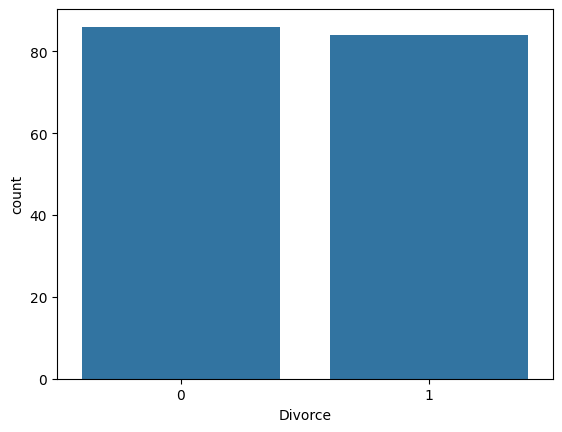

In [ ]:
sns.countplot(x = df['Divorce'])

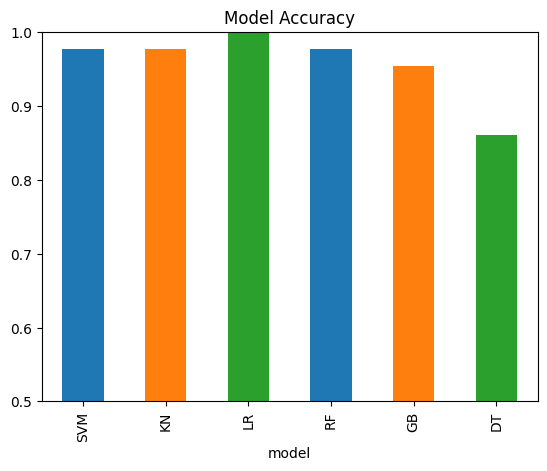

In [ ]:
X = df.drop('Divorce', axis=1)
y = df['Divorce']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model_svm = SVC(random_state=42).fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
model_kn = KNeighborsClassifier().fit(X_train, y_train)
y_pred_kn = model_kn.predict(X_test)
model_lr = LogisticRegression().fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
model_rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
model_gb = GradientBoostingClassifier(random_state=42).fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
model_dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
model_names = ['SVM', 'KN', 'LR', 'RF', 'GB', 'DT']
accuracies = [accuracy_score(y_test, y_pred_svm),
              accuracy_score(y_test, y_pred_kn),
              accuracy_score(y_test, y_pred_lr),
              accuracy_score(y_test, y_pred_rf),
              accuracy_score(y_test, y_pred_gb),
              accuracy_score(y_test, y_pred_dt)]
model_data = {'model': model_names, 'accuracy': accuracies}
model_df = pd.DataFrame(model_data)
model_df.plot(kind='bar', x='model', y='accuracy', title='Model Accuracy', legend=False,
             color=['#1F77B4', '#FF7F0E', '#2CA02C'])
plt.ylim(0.5, 1)
plt.show()

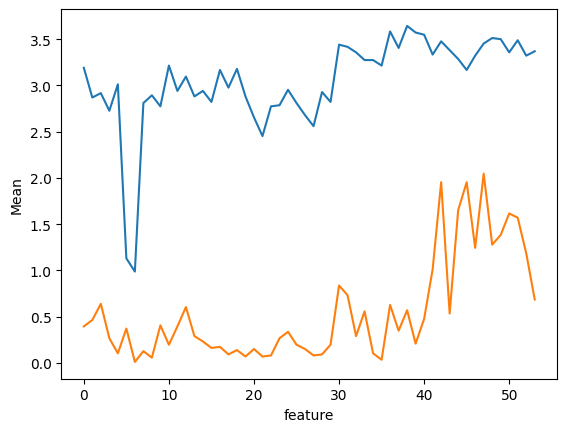

In [ ]:
com_best = df.groupby('Divorce').mean().T
com_best = com_best.reset_index()
com_best = com_best.rename(columns={'index': 'feature', 0: 'mean_0', 1: 'mean_1'})
com_best['mean_1'].plot()
com_best['mean_0'].plot()
plt.xlabel("feature")
plt.ylabel("Mean")
plt.show()

<Axes: xlabel='Divorce', ylabel='None'>

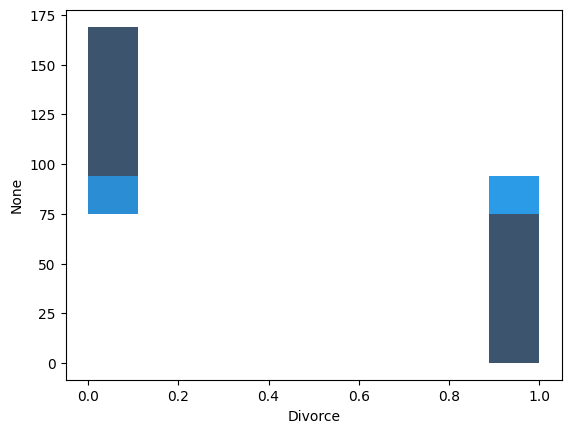

In [ ]:
sns.histplot(x=df['Divorce'],y=df.index)

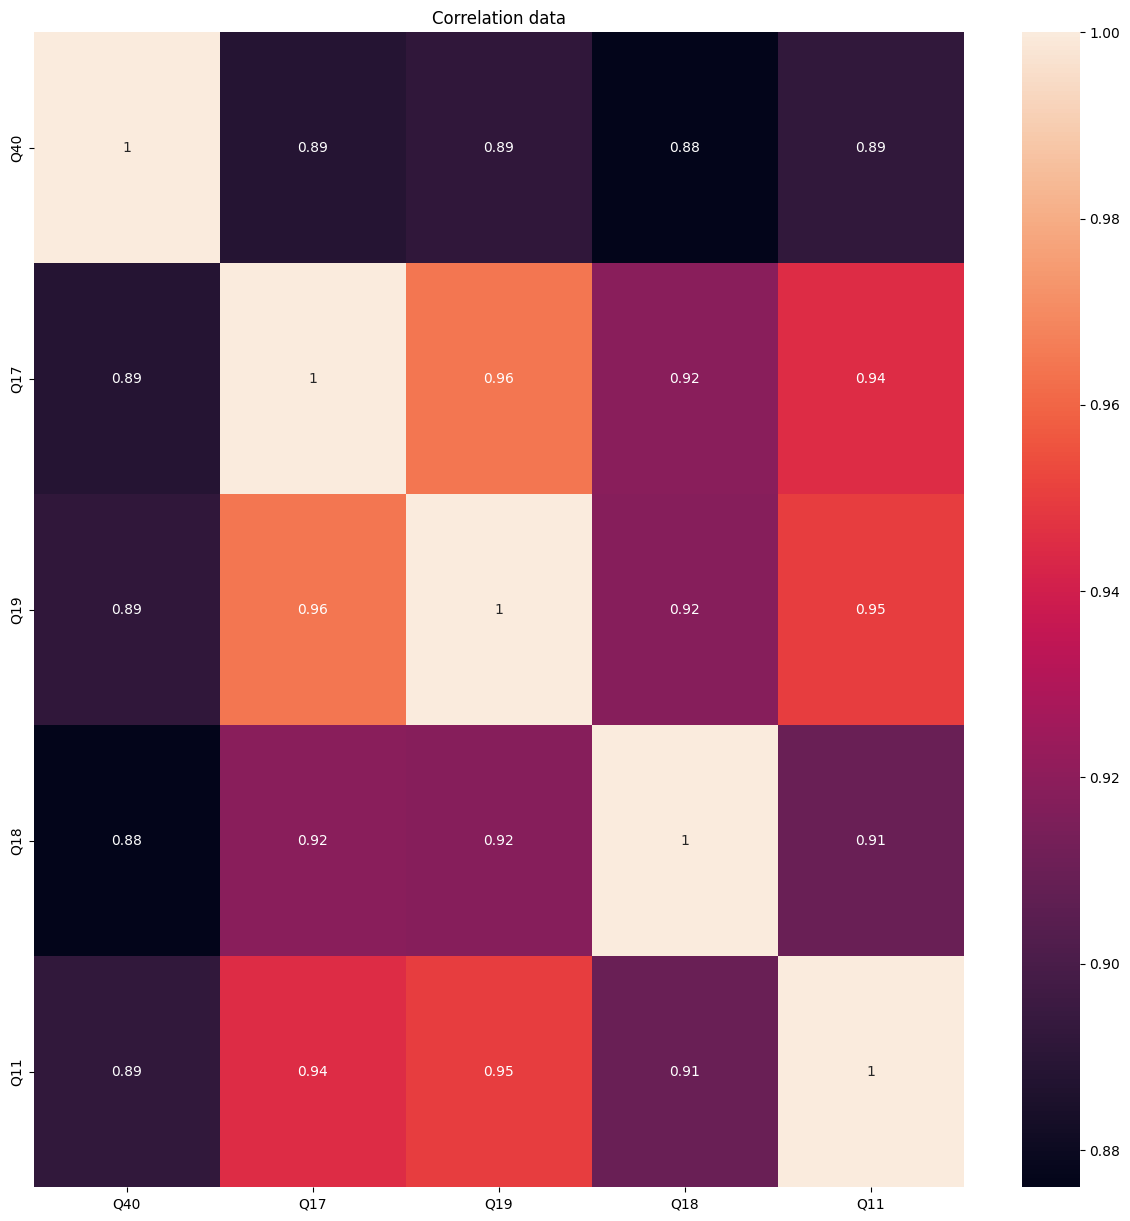

In [ ]:
correlations = df.corr()['Divorce'].abs().sort_values(ascending=False)
best = correlations[1:6].index.tolist()
plt.figure(figsize=(15,15))
sns.heatmap(np.abs(df[best].corr()), annot = True)
plt.title ("Correlation data")
plt.show()

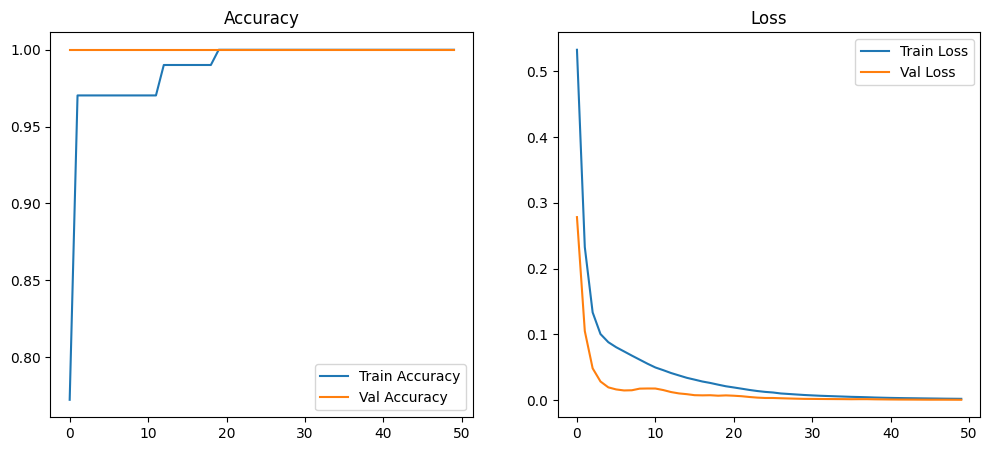

In [ ]:
X = df.drop('Divorce', axis=1)
y = df['Divorce']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# Data Preparation

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeling

In [ ]:
model_svm = SVC(random_state=42).fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)

In [ ]:
model_kn = KNeighborsClassifier().fit(X_train, y_train)
y_pred_kn = model_kn.predict(X_test)

In [ ]:
model_lr = LogisticRegression().fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

In [ ]:
model_rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

In [ ]:
model_gb = GradientBoostingClassifier(random_state=42).fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

In [ ]:
model_dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

In [ ]:
model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_ann.fit(X_train_scaled, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.6463 - loss: 0.6098 - val_accuracy: 1.0000 - val_loss: 0.2782
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9836 - loss: 0.2446 - val_accuracy: 1.0000 - val_loss: 0.1050
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9725 - loss: 0.1388 - val_accuracy: 1.0000 - val_loss: 0.0484
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9651 - loss: 0.1182 - val_accuracy: 1.0000 - val_loss: 0.0283
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9686 - loss: 0.0912 - val_accuracy: 1.0000 - val_loss: 0.0194
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9530 - loss: 0.1113 - val_accuracy: 1.0000 - val_loss: 0.0163
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9840 - loss: 0.0496 - val_accuracy: 1.0000 - val_loss: 0.0147
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9777 - loss: 0.0522 - val_accuracy: 1.0000 - val_loss: 0.0150
Epoch 9/50

In [ ]:
loss, accuracy = model_ann.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
y_pred_prob = model_ann.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9767
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.96      0.98        23

    accuracy                           0.98        43
   macro avg       0.98      0.98      0.98        43
weighted avg       0.98      0.98      0.98        43



# Evaluation

In [ ]:
print('Accuracy score SVM: {:.4f}' .format(accuracy_score(y_test, y_pred_svm)))
print('Accuracy score KN:  {:.4f}' .format(accuracy_score(y_test, y_pred_kn)))
print('Accuracy score LR:  {:.4f}' .format(accuracy_score(y_test, y_pred_lr)))
print('Accuracy score RF:  {:.4f}' .format(accuracy_score(y_test, y_pred_rf)))
print('Accuracy score GB:  {:.4f}' .format(accuracy_score(y_test, y_pred_gb)))
print('Accuracy score DT:  {:.4f}' .format(accuracy_score(y_test, y_pred_dt)))

Accuracy score SVM: 0.9767
Accuracy score KN:  0.9767
Accuracy score LR:  1.0000
Accuracy score RF:  0.9767
Accuracy score GB:  0.9535
Accuracy score DT:  0.8605


# Deployment

## Model Simulation

In [ ]:
new_data = X_test_scaled[:5]
predictions = model_ann.predict(new_data)
predicted_classes = (predictions > 0.5).astype("int32")
print("\nPredictions for new data:")
for i in range(len(new_data)):
    print(f"Sample {i+1}: Predicted class = {predicted_classes[i][0]}, Probability of divorce = {predictions[i][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step

Predictions for new data:
Sample 1: Predicted class = 0, Probability of divorce = 0.0000
Sample 2: Predicted class = 1, Probability of divorce = 1.0000
Sample 3: Predicted class = 0, Probability of divorce = 0.0027
Sample 4: Predicted class = 1, Probability of divorce = 1.0000
Sample 5: Predicted class = 0, Probability of divorce = 0.0027


## Save Model

In [ ]:
import pickle
filename = 'divorce_prediction_model.pkl'
pickle.dump(model_ann, open(filename, 'wb'))
from google.colab import files
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_ann)
tflite_model = converter.convert()
import joblib
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
with open('divorce_data.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpw2a_xfhk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 54), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135662476602896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135662476601936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135662476598096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135662476601744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135662476601360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135662476600016: TensorSpec(shape=(), dtype=tf.resource, name=None)
